# Label-based censorship reinforced by a YOLO model
## *Censura por etiquetado y reforzado con modelo YOLO*

Project workflow / *Flujo de trabajo del proyecto*

| # | EN | ES |
|---|---------|---------|
| 1 | Store images in a variable | Almacenar las imagenes en una variable |
| 2 | Read `.txt` label files (if any) | Leer archivos de etiquetado `.txt` (si tiene) |
| 3 | Run YOLO detection on each image | Detectar cada imagen con el modelo YOLO |
| 4 | Draw bounding boxes | Dibujar cajas delimitadoras |
| 5 | Save the output image | Guardar la imagen resultante |

In [9]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from glob import glob
from ultralytics import YOLO
import gc

### Variables and functions configuration
#### *Configuracion de variables y funciones*

##### Types of censorship / *Tipos de censura*

[EN] The model applies  different censorship based on the following index values:

*[ES] El modelo aplica diferentes técnicas de censura según los siguientes valores de índice:*

| # | EN | ES |
|---|---------|---------|
| 0 | Gaussian Blur| Difuminado Gaussiano |
| 1 | Solid color block | Bloque de color solido |

In [10]:
inputFilesTxt = 'imagenesFOTOS/labels'  # Input folder with label files / Carpeta de entrada con archivos de etiquetas
inputFilesImgs = 'imagenesFOTOS/images'  # Input folder with image files / Carpeta de entrada con archivos de imágenes

outputFolder = "output_images/"  # Output folder for processed images / Carpeta de salida para imágenes procesadas

model = YOLO('detectarRostroPlaca.pt')  # Load YOLO model / Cargar modelo YOLO

os.makedirs(outputFolder, exist_ok=True)  # Create output folder if it does not exist / Crear carpeta de salida si no existe
extensiones = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp")  # Supported image extensions / Extensiones de imagen soportadas

In [11]:
def imgCensorship(imgPath, x1, y1, x2, y2, censorshipStyle = 0, color = (0, 0, 0)):  # Define function to censor an image region / Definir función para censurar una región de la imagen
    if censorshipStyle == 0:  # If censorship style is blur / Si el estilo de censura es desenfoque
        # Censorship with blur / Censura con desenfoque
        roi = imgPath[y1:y2, x1:x2]  # Extract region of interest / Extraer región de interés
        if roi.size > 0:  # Check if ROI is not empty / Verificar si la ROI no está vacía
            # Calculate kernel proportional to object size (must be odd) / Calcular kernel proporcional al tamaño del objeto (debe ser impar)
            kw = max(15, (x2 - x1) // 3 * 2 + 1)  # Compute width kernel / Calcular kernel de ancho
            kh = max(15, (y2 - y1) // 3 * 2 + 1)  # Compute height kernel / Calcular kernel de alto

            # Apply Gaussian Blur / Aplicar desenfoque Gaussiano
            blurred_roi = cv2.GaussianBlur(roi, (kw, kh), sigmaX=30)  # Blur the ROI / Difuminar la ROI

            # Replace original region with blurred one / Reemplazar región original por la difuminada
            imgPath[y1:y2, x1:x2] = blurred_roi  # Assign blurred ROI back to image / Asignar ROI difuminada de vuelta a la imagen
    elif censorshipStyle == 1:  # If censorship style is rectangle / Si el estilo de censura es rectángulo
        # Censorship with rectangle / Censura con rectángulo
        cv2.rectangle(imgPath, (x1, y1), (x2, y2), color, -1)  # Draw filled rectangle / Dibujar rectángulo relleno

    return imgPath  # Return modified image / Devolver imagen modificada

### List all images
#### *Listar todas las imágenes*

Images found: 801


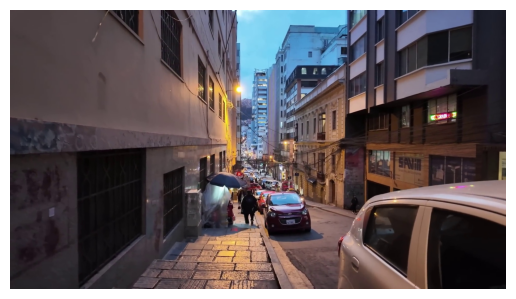

In [12]:
# List all images / Listar todas las imágenes
imgFiles = []  # Initialize empty list for image files / Inicializar lista vacía para archivos de imágenes
for ext in extensiones:  # Iterate over supported extensions / Iterar sobre extensiones soportadas
    imgFiles.extend(glob(os.path.join(inputFilesImgs, ext)))  # Add matching files from input images folder / Agregar archivos coincidentes desde la carpeta de imágenes de entrada
    imgFiles.extend(glob(os.path.join(outputFolder, ext.upper())))  # Add matching files from output folder (uppercase ext) / Agregar archivos coincidentes desde la carpeta de salida (extensión en mayúsculas)

print(f"Images found: {len(imgFiles)}")  # Print number of images found / Imprimir número de imágenes encontradas

imgExample = cv2.cvtColor(cv2.imread(imgFiles[0]), cv2.COLOR_BGR2RGB)  # Read first image and convert BGR to RGB / Leer primera imagen y convertir BGR a RGB

plt.imshow(imgExample)  # Display image with matplotlib / Mostrar imagen con matplotlib
plt.axis("off")  # Turn off axis / Desactivar ejes
plt.show()  # Show plot / Mostrar gráfico

/mnt/datos_compartidos/PortafolioProyectos/.venv/lib/python3.14/site-packages/torch/cuda/__init__.py:1174: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


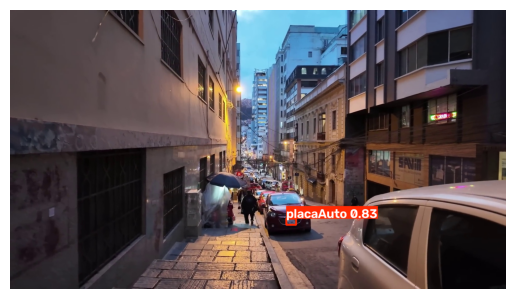

In [13]:
imgResultado = model(imgExample,imgsz=640,conf=0.3,verbose=False,max_det=10)  # Run YOLO model on example image / Ejecutar modelo YOLO en imagen de ejemplo

plt.imshow(imgResultado[0].plot())  # Display image with detections plotted / Mostrar imagen con detecciones dibujadas
plt.axis('off')  # Hide axes / Ocultar ejes
plt.show()  # Show plot / Mostrar gráfico

In [14]:
del imgExample, imgResultado  # Delete example images to free memory / Eliminar imágenes de ejemplo para liberar memoria
gc.collect()  # Run garbage collection to free memory / Ejecutar recolección de basura para liberar memoria

5411

### Consorship
#### *Censura*

In [15]:
for img_path in imgFiles:  # Iterate over each image file / Iterar sobre cada archivo de imagen
    # Get base name without extension / Obtener el nombre base sin extensión
    base_name = os.path.splitext(os.path.basename(img_path))[0]  # Extract base name / Extraer nombre base
    txt_path = os.path.join(inputFilesTxt, f"{base_name}.txt")  # Build corresponding label file path / Construir ruta del archivo de etiquetas correspondiente

    img = cv2.imread(img_path)  # Read image with OpenCV / Leer imagen con OpenCV
    if img is None:  # If image could not be read / Si la imagen no se pudo leer
        continue  # Skip to next image / Saltar a la siguiente imagen

    h, w, _ = img.shape  # Get image height, width and channels / Obtener alto, ancho y canales de la imagen

    # Check if .txt file exists and is not empty / Verificar si el archivo .txt existe y no está vacío
    if os.path.exists(txt_path) and os.path.getsize(txt_path) > 0:  # If label file exists and has content / Si el archivo de etiquetas existe y tiene contenido
        # YOLO uses spaces or tabs as separator / YOLO usa espacios o tabulaciones como separador
        df = pd.read_csv(txt_path, sep=r"\s+", header=None)  # Read label file into DataFrame / Leer archivo de etiquetas en DataFrame

        for _, row in df.iterrows():  # Iterate over each label row / Iterar sobre cada fila de etiqueta
            class_id = int(row[0])  # Extract class ID / Extraer ID de clase
            x_center = float(row[1])  # Extract normalized center X / Extraer centro X normalizado
            y_center = float(row[2])  # Extract normalized center Y / Extraer centro Y normalizado
            box_w = float(row[3])  # Extract normalized box width / Extraer ancho de caja normalizado
            box_h = float(row[4])  # Extract normalized box height / Extraer alto de caja normalizado

            # Convert normalized coordinates (0 to 1) to absolute pixels / Convertir coordenadas normalizadas (0 a 1) a píxeles absolutos
            x1 = int((x_center - box_w / 2) * w)  # Compute top-left X / Calcular X superior izquierda
            y1 = int((y_center - box_h / 2) * h)  # Compute top-left Y / Calcular Y superior izquierda
            x2 = int((x_center + box_w / 2) * w)  # Compute bottom-right X / Calcular X inferior derecha
            y2 = int((y_center + box_h / 2) * h)  # Compute bottom-right Y / Calcular Y inferior derecha

            # Clamp coordinates to image bounds / Delimitar dentro del marco de la imagen
            x1, y1 = max(0, x1), max(0, y1)  # Ensure coordinates are not negative / Asegurar que las coordenadas no sean negativas
            x2, y2 = min(w, x2), min(h, y2)  # Ensure coordinates do not exceed image size / Asegurar que las coordenadas no excedan el tamaño de la imagen

            # Apply censorship / Aplicar censura
            img = imgCensorship(img, x1, y1, x2, y2, censorshipStyle=0)  # Censor the region (style 0 = blur) / Censurar la región (estilo 0 = desenfoque) - change style as needed / cambiar estilo según sea necesario
        
        del df  # Delete DataFrame to free memory / Eliminar DataFrame para liberar memoria

    imgYOLO = model(img, imgsz=320, conf=0.3, verbose=False, max_det=100)  # Run YOLO model on the image / Ejecutar modelo YOLO en la imagen

    # Work directly on a copy of the original image / Trabajamos directamente sobre una copia de la imagen original
    imgResultado = img.copy()  # Create a copy to draw on / Crear una copia para dibujar

    # Iterate over ALL detections in the image / Iterar sobre TODAS las detecciones de la imagen
    if len(imgYOLO[0].boxes) > 0:  # If there is at least one detection / Si hay al menos una detección
        for box in imgYOLO[0].boxes.xyxy:  # Iterate over each bounding box / Iterar sobre cada caja delimitadora
            x1, y1, x2, y2 = map(int, box)  # Convert box coordinates to integers / Convertir coordenadas de caja a enteros

            # Ensure coordinates do not go outside image bounds / Asegurar que las coordenadas no salgan de los límites de la imagen
            h, w = imgResultado.shape[:2]  # Get image height and width / Obtener alto y ancho de la imagen
            x1, y1 = max(0, x1), max(0, y1)  # Clamp top-left coordinates / Delimitar coordenadas superior izquierda
            x2, y2 = min(w, x2), min(h, y2)  # Clamp bottom-right coordinates / Delimitar coordenadas inferior derecha

            imgResultado = imgCensorship(imgResultado, x1, y1, x2, y2, censorshipStyle=0)  # Apply censorship to detection / Aplicar censura a la detección

    # Show image with drawn boxes / Mostrar la imagen con las cajas dibujadas

    cv2.imwrite(os.path.join(outputFolder, os.path.basename(img_path)), imgResultado)  # Save processed image to output folder / Guardar imagen procesada en carpeta de salida
    del img, imgYOLO, imgResultado  # Delete images to free memory / Eliminar imágenes para liberar memoria
    gc.collect() # Run garbage collection to free memory / Ejecutar recolección de basura para liberar memoria